<h3>Trader Performance Analysis Based on Market Sentiment</h3>

In [5]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# loading datasets
sentiment = pd.read_csv("fear_greed_index.csv")
trade = pd.read_csv("historical_data.csv")

In [3]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
trade.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [8]:
# no.of rows
print(sentiment.shape)
print(trade.shape)

(2644, 4)
(211224, 16)


In [10]:
# column names
print(sentiment.columns)
print(trade.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [11]:
# checking missing values
print(sentiment.isnull().sum())
print(trade.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [12]:
# checking duplicates
print(sentiment.duplicated().sum())
print(trade.duplicated().sum())

0
0


In [17]:
# checking data types
print(sentiment.info())
print(trade.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 n

In [19]:
# converting time stamps
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [21]:
trade['Timestamp IST'] = pd.to_datetime(trade['Timestamp IST'], dayfirst=True)

In [22]:
sentiment['Date'] = sentiment['date'].dt.date
trade['Date'] = trade['Timestamp IST'].dt.date

In [23]:
align = pd.merge(trade, sentiment[['Date', 'classification']], on='Date', how='left')

In [26]:
print(align.head())
print(align['classification'].isnull().sum())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0

In [29]:
# key metrics
daily_pnl = align.groupby(['Account', 'Date'])['Closed PnL'].sum().reset_index()

In [30]:
align['win'] = align['Closed PnL'] > 0

win_rate = align.groupby('Account')['win'].mean().reset_index()
win_rate.rename(columns={'win': 'win_rate'}, inplace=True)

In [43]:
avg_trade_size = align.groupby('Account')['Size USD'].mean().reset_index()

In [40]:
avg_pnl = align.groupby('Account')['Closed PnL'].mean().reset_index()

In [35]:
trades_per_day = align.groupby('Date').size().reset_index(name='trade_count')

In [37]:
long_short_ratio = align['Side'].value_counts(normalize=True)

<h5>Analysis</h5>

In [44]:
# Fear Vs Greed
align.groupby('classification')['Closed PnL'].mean()

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

In [45]:
align.groupby('classification')['win'].mean()

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64

In [46]:
align.groupby('classification')['Closed PnL'].sum()

classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64

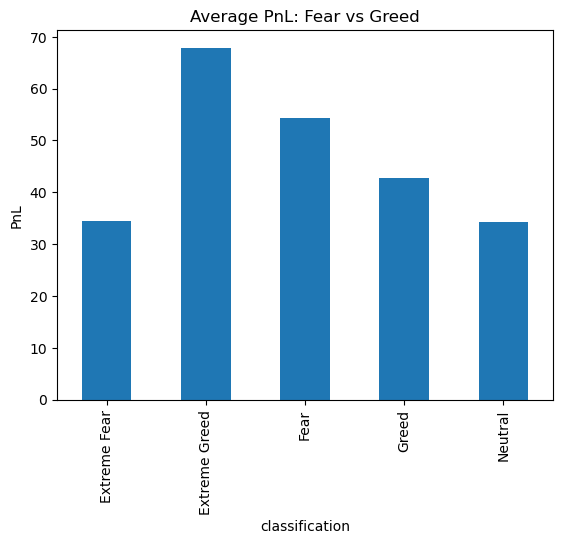

In [49]:
import matplotlib.pyplot as plt

align.groupby('classification')['Closed PnL'].mean().plot(kind='bar')
plt.title("Average PnL: Fear vs Greed")
plt.ylabel("PnL")
plt.show()

<p>Traders achieve the highest average profits during Extreme Greed periods, indicating strong bullish market conditions.
Lower profitability is observed during Extreme Fear and Neutral conditions.</p>

In [50]:
# Behavior Chnages
align.groupby('classification').size()

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64

In [52]:
align.groupby('classification')['Size USD'].mean()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

In [54]:
align.groupby(['classification', 'Side']).size().unstack()

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


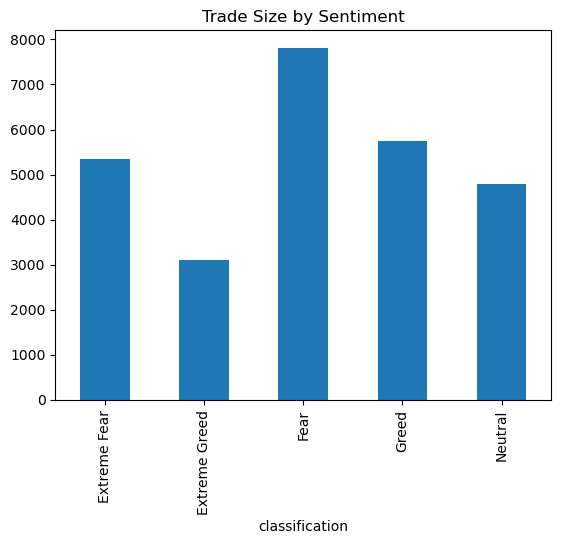

In [57]:
align.groupby('classification')['Size USD'].mean().plot(kind='bar')
plt.title("Trade Size by Sentiment")
plt.show()

<p>Traders achieve the highest average profits during Extreme Greed periods, indicating strong bullish market conditions.
Lower profitability is observed during Extreme Fear and Neutral conditions.</p>

In [61]:
# Segments
# 1.high vs low levarage traders
trade_counts = align['Account'].value_counts()

align['trader_type'] = align['Account'].apply(
    lambda x: 'frequent' if trade_counts[x] > 50 else 'infrequent'
)

In [65]:
# 2.winners Vs losers
total_pnl = align.groupby('Account')['Closed PnL'].sum()

align['trader_perf'] = align['Account'].apply(
    lambda x: 'winner' if total_pnl[x] > 0 else 'loser'
)

In [66]:
align.groupby(['trader_type', 'classification'])['Closed PnL'].mean()

trader_type  classification
frequent     Extreme Fear      34.537862
             Extreme Greed     67.892861
             Fear              54.290400
             Greed             42.743559
             Neutral           34.307718
Name: Closed PnL, dtype: float64

<h5>Strategy Ideas</h5>